# Day 6 — Multimodal LLMs
**GenAI 403 | Week 3**

### What we cover today
| # | Topic | Paid | Free |
|---|---|---|---|
| 1 | Image Captioning | GPT-4o Vision | Ollama LLaVA |
| 2 | Image Q&A | GPT-4o Vision | Ollama LLaVA |
| 3 | OCR — Extract text from images | GPT-4o Vision | EasyOCR |
| 4 | Audio Transcription | OpenAI Whisper API | faster-whisper (local) |
| 5 | Visual Prompt Chaining | Gemini 1.5 Flash | Ollama LLaVA chained |

> **Two tracks:**
> - 🔵 **Paid** — OpenAI GPT-4o Vision + Whisper API + Google Gemini
> - 🟢 **Free** — Ollama LLaVA (local vision) + faster-whisper + EasyOCR
>
> Each section shows both. Set `USE_FREE` in Section 1.

---
## 0 — Install Dependencies
Run once, then **restart the kernel**.

In [1]:
%pip install -q \
    openai \
    google-generativeai \
    langchain-ollama \
    faster-whisper \
    easyocr \
    pillow \
    requests \
    python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---
## 1 — Load Keys & Choose Track

Your `.env` file should contain:
```
OPENAI_API_KEY=sk-your-openai-key
GEMINI_API_KEY=your-gemini-key
```
Get a **free** Gemini key at: **aistudio.google.com → Get API Key** (no billing needed)

🟢 **Free track prerequisite:**
```bash
ollama pull llava        # vision model (~4GB)
ollama pull llama3.2     # text model
```

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

print("OpenAI key:", "✅ loaded" if OPENAI_API_KEY else "❌ missing")
print("Gemini key:", "✅ loaded" if GEMINI_API_KEY else "❌ missing")

OpenAI key: ✅ loaded
Gemini key: ✅ loaded


In [5]:
# ── Choose your track ─────────────────────────────────────────────────────
USE_FREE = False   # False = OpenAI + Gemini | True = Ollama + EasyOCR + faster-whisper

track = "🟢 FREE (Ollama LLaVA + EasyOCR + faster-whisper)" if USE_FREE else "🔵 PAID (OpenAI + Gemini)"
print("Active track:", track)

Active track: 🔵 PAID (OpenAI + Gemini)


Testing image load...


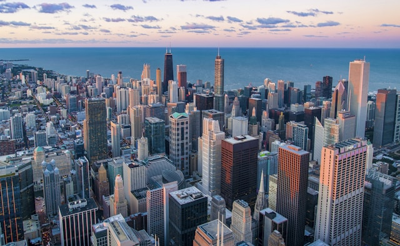

✅ Image loaded successfully


In [6]:
# ── Helper: load any image as base64 (needed for API calls) ───────────────

# ── Fixed helper + reliable test images ───────────────────────────────────
import base64
import requests
from PIL import Image
from io import BytesIO

# Reliable public images for demos
IMAGES = {
    "street":   "https://images.unsplash.com/photo-1477959858617-67f85cf4f1df?w=640",
    "document": "https://images.unsplash.com/photo-1568667256549-094345857637?w=640",
    "food":     "https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=640",
}

# Pick one to use throughout
IMAGE_SOURCE = IMAGES["street"]


def image_to_base64(source):
    """Accepts a file path or URL. Returns base64 string + detected media type."""
    if source.startswith("http"): # checks whether the source is a URL or a local file path.
        headers = {"User-Agent": "Mozilla/5.0"}   # some servers block no-agent requests
        response = requests.get(source, headers=headers, timeout=10) # makes an HTTP GET request to download the image from the URL, with a timeout of 10 seconds.
        response.raise_for_status() # raises an error if the request failed (e.g., 404 or 500)
        image_data = response.content # contains the raw bytes of the image downloaded from the URL.
    else:
        with open(source, "rb") as f:
            image_data = f.read()

    # Detect format via PIL before encoding
    img = Image.open(BytesIO(image_data)) # opens the image from the raw bytes to detect its format (e.g., JPEG, PNG).
    fmt = img.format.lower() if img.format else "jpeg" # defaults to jpeg if format can't be detected
    b64 = base64.b64encode(image_data).decode("utf-8") # encodes the raw image bytes into a base64 string, which is a common format for embedding binary data in text-based formats like JSON.
    return b64, fmt   # returns both so API calls use correct mime type


def show_image(source, width=400):
    """Displays image from URL or file path in notebook."""
    if source.startswith("http"):
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(source, headers=headers, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
    else:
        img = Image.open(source)

    ratio = width / img.width # calculate the aspect ratio to maintain proportions when resizing
    img = img.resize((width, int(img.height * ratio))) # resizes the image to the specified width while maintaining the aspect ratio
    display(img)


# Test it
print("Testing image load...")
show_image(IMAGE_SOURCE)
print("✅ Image loaded successfully")

---
## 2 — Image Captioning

Image captioning is the simplest vision task — show the model an image and ask it to describe what it sees in natural language. 

This is also called image-to-text.

Feed an image → LLM describes what it sees.
This is the foundation of all vision tasks.

=== Image Captioning ===



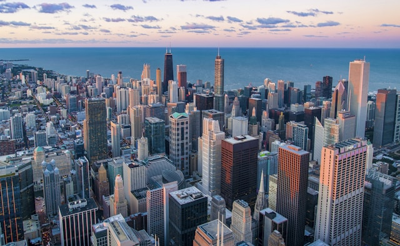

🔵 GPT-4o Caption:
 This image depicts an aerial view of a bustling cityscape at sunset, showcasing a diverse array of skyscrapers with varying architectural styles. The buildings are bathed in a warm, soft glow from the setting sun, while a large body of water is visible in the background, enhancing the city's scenic beauty. The sky is dotted with clouds, adding depth and texture to the vibrant horizon.


In [7]:
# ── 🔵 PAID: GPT-4o Vision Captioning ────────────────────────────────────
from openai import OpenAI

def caption_image_openai(image_source):
    client = OpenAI(api_key=OPENAI_API_KEY) # initializes the OpenAI client with the provided API key, allowing you to make requests to OpenAI's API.
    b64 = image_to_base64(image_source)
    # GPT-4o is the multimodal version of GPT-4. It accepts both text and images in the same message. 
    # GPT-4o-mini cannot do vision.
    # content is a list — this is how multimodal messages work. Each item in the list is either type: text or type: image_url.

    response = client.chat.completions.create( # creates a chat completion using the OpenAI API, which generates a response based on the provided messages and model.
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text",       "text": "Describe this image in 2-3 sentences."},
                    {"type": "image_url",  "image_url": {"url": f"data:image/png;base64,{b64}"}}
                ]
            }
        ],
        max_tokens=300 # limits the length of the generated caption (adjust as needed)
    )
    return response.choices[0].message.content # extracts the generated caption from the API response


# ── 🟢 FREE: Ollama LLaVA Captioning ─────────────────────────────────────
import subprocess, json

def caption_image_ollama(image_source):
    """
    Calls Ollama LLaVA via its REST API.
    LLaVA = Large Language and Vision Assistant — free, runs locally.
    """
    b64, fmt  = image_to_base64(image_source) # converts the image to a base64 string and detects its format (e.g., JPEG, PNG) to ensure the API call uses the correct MIME type.
    
    # prepares the payload for the API request, specifying the model to use (LLaVA), the prompt for captioning, 
    # the image in base64 format, and whether to stream the response.
    payload = {
        "model": "llava",
        "prompt": "Describe this image in 2-3 sentences.",
        "images": [b64],
        "stream": False
    } 
    # makes a POST request to the Ollama API endpoint to generate a caption based on the provided image and prompt. 
    # The response is expected to be in JSON format, 
    # and the generated caption is extracted from the "response" field of the JSON response.

    response = requests.post("http://localhost:11434/api/generate", json=payload) 
    return response.json()["response"]


# ── Run ───────────────────────────────────────────────────────────────────
print("=== Image Captioning ===\n")
show_image(IMAGE_SOURCE)

if USE_FREE:
    # •	LLaVA (Large Language and Vision Assistant) is an open-source vision model from Microsoft Research, fine-tuned on LLaMA. 
    # It runs locally via Ollama. Ollama runs as a local HTTP server on port 11434. We call it like any other REST API.
    caption = caption_image_ollama(IMAGE_SOURCE)
    print("🟢 LLaVA Caption:\n", caption)
else:
    caption = caption_image_openai(IMAGE_SOURCE)
    print("🔵 GPT-4o Caption:\n", caption)

---
## 3 — Image Q&A

Captioning gives you a generic description. Image Q&A lets you ask targeted, specific questions about an image. 

Same image, but now we control exactly what we want to know.

Ask specific questions about an image — not just describe it.
This is used in customer support, medical imaging, document review etc.

=== Image Q&A ===



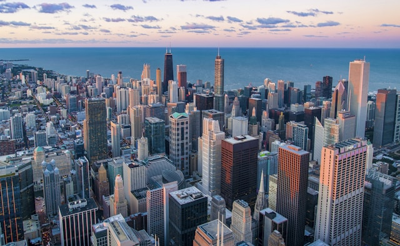


Q: What colors are dominant in this image?
A: The dominant colors in the image are blue, due to the sky and water, and various shades of gray and white from the buildings. There are also hints of pink and orange from the sunset light reflecting on the buildings.

Q: What objects can you identify in this image?
A: The image depicts a cityscape featuring numerous skyscrapers and high-rise buildings. In the background, there's a body of water, likely a lake or ocean, under a sky with clouds. The scene is set during a time of day when the lighting casts soft shadows, possibly around sunset or sunrise.

Q: Is there any text visible in this image?
A: No, there is no visible text in this image.



In [8]:
def ask_about_image_openai(image_source, question):
    """GPT-4o answers a specific question about the image."""
    client = OpenAI(api_key=OPENAI_API_KEY)
    b64, fmt = image_to_base64(image_source)

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text",      "text": question},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}}
                ]
            }
        ],
        max_tokens=300
    )
    return response.choices[0].message.content


def ask_about_image_ollama(image_source, question):
    """LLaVA answers a specific question about the image."""
    b64, fmt = image_to_base64(image_source)
    payload = {
        "model": "llava",
        "prompt": question,
        "images": [b64],
        "stream": False
    }
    response = requests.post("http://localhost:11434/api/generate", json=payload)
    return response.json()["response"]


# ── Run: ask multiple questions about the same image ──────────────────────
questions = [
    "What colors are dominant in this image?",
    "What objects can you identify in this image?",
    "Is there any text visible in this image?",
]

print("=== Image Q&A ===\n")
show_image(IMAGE_SOURCE)
print()

for question in questions:
    print(f"Q: {question}")
    if USE_FREE:
        answer = ask_about_image_ollama(IMAGE_SOURCE, question)
    else:
        answer = ask_about_image_openai(IMAGE_SOURCE, question)
    print(f"A: {answer}\n")

---
## 4 — OCR: Extract Text from Images

OCR = Optical Character Recognition — reading text that is embedded inside an image.
Use cases: scanned documents, receipts, forms, screenshots, ID cards.

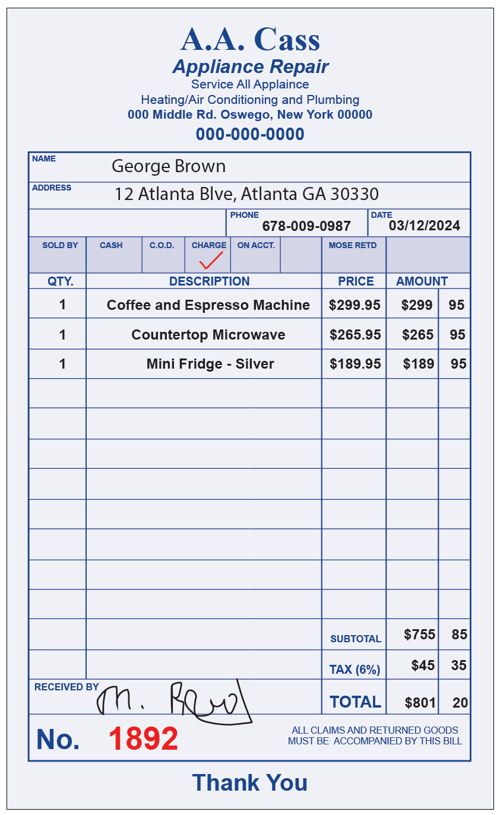

In [9]:
# This Wikipedia screenshot contains readable text
# A receipt/document image that works reliably for OCR demos
# OCR_IMAGE = "https://images.unsplash.com/photo-1572635196237-14b3f281503f?w=640"  # product label with text

# OR use a local screenshot — most reliable option 
# Save any screenshot to the same folder as the notebook and use:
# OCR_IMAGE = "screenshot.png"

# ── Load local OCR image ───────────────────────────────────────────────────
OCR_IMAGE = "sample_ocr.png"

show_image(OCR_IMAGE, width=500)


In [ ]:
# ── 🔵 PAID: GPT-4o OCR ──────────────────────────────────────────────────
def ocr_openai(image_source):
    """Uses GPT-4o vision to extract all text from an image."""
    client = OpenAI(api_key=OPENAI_API_KEY)
    # b64 = image_to_base64(image_source)
    b64, fmt = image_to_base64(image_source)

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text",      "text": "Extract ALL text visible in this image. Return only the extracted text, nothing else."},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}}
                ]
            }
        ],
        max_tokens=500
    )
    return response.choices[0].message.content


# ── 🟢 FREE: EasyOCR ─────────────────────────────────────────────────────
def ocr_easyocr(image_source):
    """
    EasyOCR — open source OCR, supports 80+ languages.
    Downloads model on first run (~100MB). No API key needed.
    """
    import easyocr
    import numpy as np

    reader = easyocr.Reader(["en"], gpu=False)  # set gpu=True if you have CUDA

    if image_source.startswith("http"):
        response = requests.get(image_source) # download the image from the URL
        # converts the raw bytes of the downloaded image into a NumPy array, which is a common format for image processing in Python.
        image_array = np.frombuffer(response.content, dtype=np.uint8) 
        import cv2 # imports the OpenCV library, which is commonly used for image processing tasks in Python.
        img = cv2.imdecode(image_array, cv2.IMREAD_COLOR) # decodes the image data into an image format that EasyOCR can process.
        # performs OCR on the image using EasyOCR, which returns a list of results containing the bounding box, 
        # extracted text, and confidence score for each detected text element in the image.
        results = reader.readtext(img) 
    else:
        # performs OCR on the local image file specified by image_source, returning a list of results containing the bounding box, 
        # extracted text, and confidence score for each detected text element in the image.
        results = reader.readtext(image_source) 
    # results is a list of tuples: (bounding_box, text, confidence_score).
    # The code then filters the results to include only those with a confidence score greater than 0.3 
    # and joins the extracted text into a single string, which is returned as the output of the function.
    extracted = "\n".join(text for _, text, confidence in results if confidence > 0.3)
    return extracted


# ── Run ───────────────────────────────────────────────────────────────────
print("=== OCR — Extract Text from Image ===\n")

if USE_FREE:
    print("🟢 EasyOCR Result:")
    text = ocr_easyocr(OCR_IMAGE)
else:
    print("🔵 GPT-4o OCR Result:")
    text = ocr_openai(OCR_IMAGE)

print(text)

=== OCR — Extract Text from Image ===

🔵 GPT-4o OCR Result:
A.A. Cass  
Appliance Repair  
Service All Appliance  
Heating/Air Conditioning and Plumbing  
000 Middle Rd. Oswego, New York 00000  
000-000-0000

NAME  
George Brown

ADDRESS  
12 Atlanta Blve, Atlanta GA 30330

PHONE  
678-009-0987

DATE  
03/12/2024

SOLD BY  

CASH  

C.O.D.  

CHARGE  

ON ACCT.  

MOSE RETD  

QTY.  

DESCRIPTION  

PRICE  

AMOUNT  

1  

Coffee and Espresso Machine  

$299.95  

$299  

95  

1  

Countertop Microwave  

$265.95  

$265  

95  

1  

Mini Fridge - Silver  

$189.95  

$189  

95  

SUBTOTAL  

$755  

85  

TAX (6%)  

$45  

35  

TOTAL  

$801  

20  

RECEIVED BY  

No.   

1892  

ALL CLAIMS AND RETURNED GOODS  
MUST BE ACCOMPANIED BY THIS BILL

Thank You


---
## 5 — Audio Transcription with Whisper

Whisper converts speech → text.
Use cases: meeting notes, voice commands, subtitles, call transcripts.

We first create a short sample audio file, then transcribe it.

In [12]:
# ── Create a sample audio file locally 
%pip install -q gtts   # Google Text-to-Speech — free, no API key

# imports the gTTS class from the gtts library, which is used for converting text to speech using Google's Text-to-Speech API.
# This allows you to create audio files from text input without needing an API key, as gTTS uses Google's free TTS service under the hood.

from gtts import gTTS 
# Create a short speech clip to transcribe
text = (
    "Hello, this is a test audio for the Whisper transcription demo. "
    "My name is Ali and I would like to book an appointment with a cardiologist "
    "at City Hospital for next Monday at ten am."
)

tts = gTTS(text=text, lang="en", slow=False)
AUDIO_FILE = "sample_audio.mp3"
tts.save(AUDIO_FILE)
print(f"Audio created: {AUDIO_FILE}")

# Play it in the notebook
from IPython.display import Audio, display
display(Audio(AUDIO_FILE))


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Audio created: sample_audio.mp3


In [17]:
# # Step 1 — Download a sample audio file to transcribe
# # This is a short public domain English speech clip

# AUDIO_URL  = "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3"
# AUDIO_FILE = "sample_audio.mp3"

# # Use a short Wikipedia audio sample instead — clearly spoken words
# AUDIO_URL = "https://upload.wikimedia.org/wikipedia/commons/1/1f/Ratatouille_film.ogg"
# AUDIO_FILE = "sample_audio.ogg"

# import urllib.request
# urllib.request.urlretrieve(AUDIO_URL, AUDIO_FILE)
# print(f"Audio downloaded: {AUDIO_FILE}")

# # Play it in the notebook
# from IPython.display import Audio, display
# display(Audio(AUDIO_FILE))

In [13]:
# ── 🔵 PAID: OpenAI Whisper API ───────────────────────────────────────────
def transcribe_openai(audio_file):
    """
    Sends audio to OpenAI Whisper API.
    Supports mp3, mp4, wav, ogg, flac, m4a.
    """
    client = OpenAI(api_key=OPENAI_API_KEY)

    with open(audio_file, "rb") as f:
        # OpenAI's dedicated transcription endpoint. Completely separate from the chat completions endpoint.
        # creates a transcription of the audio file using OpenAI's Whisper API. It sends the audio file, 
        # specifies the model to use for transcription (whisper-1), and sets the language to English.
        transcription = client.audio.transcriptions.create( 
            model="whisper-1",
            file=f,
            language="en"
        )
    return transcription.text


# ── 🟢 FREE: faster-whisper (local) ──────────────────────────────────────
def transcribe_local(audio_file):
    """
    faster-whisper runs OpenAI's Whisper model locally.
    No API key. Model downloads once (~150MB for 'tiny').
    Models: tiny, base, small, medium, large-v3
    """
    # imports the WhisperModel class from the faster_whisper library, which is a local implementation of OpenAI's Whisper model for audio transcription. 
    # This allows you to run the model on your own machine without needing to make API calls to OpenAI, providing a free alternative for transcribing audio files.

    from faster_whisper import WhisperModel 
    # 'tiny' is fastest, 'small' is better quality
    # 'tiny' is the smallest and fastest model, while 'small' offers better transcription quality at the cost of increased resource usage and slower performance.
    model = WhisperModel("tiny", device="cpu", compute_type="int8") # "int8" quantizes the model to 8-bit integers. Uses less RAM and runs faster on CPU. Minor accuracy tradeoff.
    # performs transcription on the provided audio file, returning both the transcribed segments and information about the detected language and confidence.
    segments, info = model.transcribe(audio_file, language="en") # returns segments (list of time-stamped text chunks) and info (language, duration, etc.).

    print(f"Detected language: {info.language} (confidence: {info.language_probability:.0%})") # prints the detected language and its confidence level as a percentage.
    transcript = " ".join(segment.text for segment in segments) 
    return transcript


# ── Run ───────────────────────────────────────────────────────────────────
print("=== Audio Transcription ===\n")

if USE_FREE:
    print("🟢 faster-whisper (local) Transcription:")
    transcript = transcribe_local(AUDIO_FILE)
else:
    print("🔵 OpenAI Whisper API Transcription:")
    transcript = transcribe_openai(AUDIO_FILE)

print()
print(transcript)

=== Audio Transcription ===

🔵 OpenAI Whisper API Transcription:

Hello, this is a test audio for the whisper transcription demo. My name is Ali and I would like to book an appointment with a cardiologist at City Hospital for next Monday at 10 a.m.


---
## 6 — Gemini Vision API + Visual Prompt Chaining

**Visual prompt chaining** = the output of one vision call becomes the input of the next. The image is processed once — everything after that is pure text. 

Example chain we build:
```
Image → Step 1: Caption it → Step 2: Translate caption → Step 3: Suggest use cases
```

🟢 **Free:** Gemini 2.5 Flash has a generous free tier at aistudio.google.com

Gemini is Google's multimodal model family. We use Gemini 2.5 Flash today — it supports text, images, audio, and video in a single request. 

The free tier gives us 10 requests per minute with no billing.

In [14]:
# ── 🔵 PAID / 🟢 FREE: Gemini Vision ─────────────────────────────────────
# Gemini 2.5 Flash is FREE up to 10 requests/min on the free tier
# Get your key at: aistudio.google.com → Get API Key (no billing needed)

import google.generativeai as genai
from PIL import Image
from io import BytesIO

genai.configure(api_key=GEMINI_API_KEY) # authenticates the Google generativeai SDK globally. All subsequent calls use this key.
gemini_model = genai.GenerativeModel("gemini-2.5-flash") # — instantiates the model

def load_image_for_gemini(image_source):
    """Returns a PIL Image from URL or file path for Gemini."""
    # Gemini's SDK accepts PIL Image objects directly — unlike OpenAI which requires base64 strings. Google handles the encoding internally.
    # For URL images: requests.get() downloads the bytes, BytesIO wraps them, PIL.Image.open() creates the image object.
    # For local files: PIL.Image.open(image_source) reads directly from disk.
    if image_source.startswith("http"):
        response = requests.get(image_source)
        return Image.open(BytesIO(response.content))
    return Image.open(image_source)

def gemini_vision(image_source, prompt):
    """Single Gemini vision call."""
    img = load_image_for_gemini(image_source)
    # Gemini's multimodal API takes a list of items. Items can be strings, PIL Images, or video files in any order.
    response = gemini_model.generate_content([prompt, img])
    return response.text # the generated text response from Gemini, which contains the model's answer to the prompt based on the content of the image.

print("Gemini Vision ready")

Gemini Vision ready


/Users/irumzahra/Library/CloudStorage/OneDrive-Personal/Desktop/GenAI403/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/g8/3fn287yx2y5c2h5txycsrc9h0000gn/T/ipykernel_28033/341104185.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


### Before we chain, let's see a single Gemini vision call — same image captioning task we did with GPT-4o and LLaVA, now with Gemini. 

=== Gemini Vision — Image Captioning ===



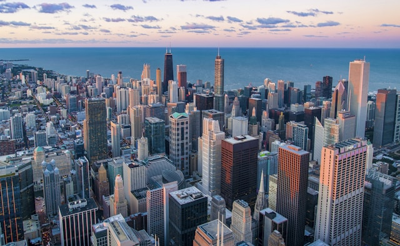


Gemini says:
 This expansive aerial photograph showcases a vibrant cityscape, likely Chicago, at either dawn or dusk. Numerous skyscrapers and high-rise buildings of varying architectural styles stretch across the frame, bathed in warm golden light that creates striking highlights and shadows. In the background, a vast body of water, likely Lake Michigan, meets a softly colored sky with scattered clouds.


In [15]:
# ── Single Gemini Vision call — Image Captioning ──────────────────────────
print("=== Gemini Vision — Image Captioning ===\n")
show_image(IMAGE_SOURCE)
print()

caption = gemini_vision(IMAGE_SOURCE, "Describe this image in 2-3 sentences.")
print("Gemini says:\n", caption)

=== Visual Prompt Chaining ===



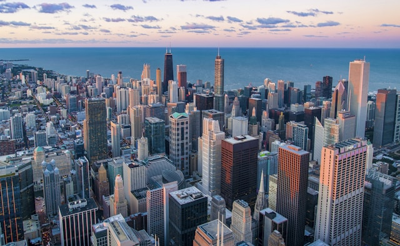


Step 1 — Describe the image
Output: This image presents a stunning, high-angle aerial view of a sprawling metropolis situated alongside a vast body of water, likely at either sunrise or sunset given the soft, warm light.

**Overall Composition and Light:**
The scene is dominated by an immense urban landscape, filling approximately two-thirds of the frame, with a large expanse of water and a soft, pastel-colored sky occupying the upper third. The lighting is characteristic of the "golden hour," bathing many of the buildings in warm hues of orange, pink, and yellow, while others remain in deeper shadow, creating significant contrast and depth. The horizon line is very clear, separating the city from the water and sky.

**The Sky and Water:**
The sky features a delicate gradient of colors, transitioning from a pale, creamy orange and pink directly above the horizon to a soft, light blue higher up. Scattered, wispy clouds, illuminated from beneath, are visible across the upper portion of 

In [16]:
# ── Visual Prompt Chaining ────────────────────────────────────────────────
# Step 1 output → Step 2 input → Step 3 input
# The image is only loaded once (Step 1). Steps 2 & 3 work on text only.

from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama

# Text LLM for steps 2 and 3 (no image needed after step 1)
# selects the text LLM based on the track. Note: text_llm is a pure text model — it never sees the image.
text_llm = ChatOllama(model="llama3.2") if USE_FREE else ChatOpenAI(
    model="gpt-4o-mini", api_key=OPENAI_API_KEY
)

print("=== Visual Prompt Chaining ===\n")
show_image(IMAGE_SOURCE)
print()

# ── Step 1: Describe the image (Vision call) ──────────────────────────────
print("Step 1 — Describe the image")
if USE_FREE:
    step1_output = caption_image_ollama(IMAGE_SOURCE)
else:
    step1_output = gemini_vision(IMAGE_SOURCE, "Describe this image in detail.") # this is the only vision call in the chain. step1_output is a plain string description.
print(f"Output: {step1_output}\n")

# ── Step 2: Translate the caption to Urdu (Text call) ─────────────────────
print("Step 2 — Translate description to Urdu")
# the f-string injects the Step 1 output into the prompt. The text LLM translates it. 
# Note that the text LLM never sees the image — it only works with the caption generated by the vision model in Step 1.
step2_prompt = f"Translate this image description to Urdu:\n\n{step1_output}"
step2_output = text_llm.invoke(step2_prompt).content
print(f"Output: {step2_output}\n")

# ── Step 3: Suggest real-world use cases based on the image (Text call) ───
print("Step 3 — Suggest 3 real-world use cases for what is shown")
# step3_prompt again uses step1_output — not step2_output. Both Step 2 and Step 3 build on the original description, not on each other. 
# This shows how you can use the same vision output for multiple different text-based follow-up tasks.
step3_prompt = f"Based on this image description:\n\n{step1_output}\n\nSuggest 3 real-world business or educational use cases."
step3_output = text_llm.invoke(step3_prompt).content # standard LangChain invocation. Returns the model's response as a string.
print(f"Output: {step3_output}\n")

print("Chain complete ✅")

---
## 7 — Bonus: Voice Command Pipeline

Combine Whisper + LLM to build a complete **speech → understanding → response** pipeline.

We now combine two modalities in one pipeline: audio understanding (Whisper) and text generation (LLM). 

This is the pattern behind voice assistants like Siri, Google Assistant, and Alexa — minus the text-to-speech at the end.

```
Audio File → Whisper (transcribe) → LLM (understand + respond) → Text Response
```

In [17]:
from langchain_core.messages import SystemMessage, HumanMessage

def voice_command_pipeline(audio_file):
    """
    Full pipeline:
    1. Transcribe audio → text (Whisper)
    2. Send text to LLM as a command → get response
    """
    print("Step 1 — Transcribing audio...")
    if USE_FREE:
        transcript = transcribe_local(audio_file)
    else:
        transcript = transcribe_openai(audio_file)
    print(f"Transcript : {transcript}\n")

    print("Step 2 — Sending transcript to LLM...")
    system = "You are a helpful voice assistant. The user has spoken a command. Respond helpfully and concisely."
    response = text_llm.invoke([
        SystemMessage(content=system),
        HumanMessage(content=transcript)
    ])
    print(f"Response   : {response.content}")


print("=== Voice Command Pipeline ===\n")
voice_command_pipeline(AUDIO_FILE)

=== Voice Command Pipeline ===

Step 1 — Transcribing audio...
Transcript : Hello, this is a test audio for the whisper transcription demo. My name is Ali and I would like to book an appointment with a cardiologist at City Hospital for next Monday at 10 a.m.

Step 2 — Sending transcript to LLM...
Response   : Hello Ali! Unfortunately, I can't book appointments directly. I recommend contacting City Hospital's cardiology department either through their phone number or website to schedule your appointment for next Monday at 10 a.m. If you need help finding that information, let me know!


---
## Summary

| Capability | 🔵 Paid | 🟢 Free |
|---|---|---|
| **Image Captioning** | GPT-4o Vision | Ollama LLaVA |
| **Image Q&A** | GPT-4o Vision | Ollama LLaVA |
| **OCR** | GPT-4o Vision | EasyOCR |
| **Audio Transcription** | OpenAI Whisper API | faster-whisper (local) |
| **Vision + Text Chaining** | Gemini 1.5 Flash + GPT-4o-mini | Ollama LLaVA + llama3.2 |
| **Voice Command Pipeline** | Whisper + GPT-4o-mini | faster-whisper + llama3.2 |

### Key concepts
- **Multimodal** = a model that understands more than one type of input (text + image + audio)
- **Base64 encoding** = how images are sent inside JSON API requests
- **Visual prompt chaining** = vision output becomes text input for the next step
- **Whisper** = OpenAI's speech-to-text model, available both via API and locally
- **LLaVA** = open-source vision model that runs via Ollama with no API key

> **Next session:** Day 7 — Tool-Augmented Agents